# RSSI Fingerprinting — Advanced Model Training

Trains multiple models (KNN, Random Forest, Gradient Boosting) using:
- **Raw features**: 4 RSSI values
- **Statistical features**: mean + stdev per router over a sliding window (8 features)

Picks the best model automatically.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import cross_val_score, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [18]:
DATA_FILE = '../fingerprint_data.csv'
df = pd.read_csv(DATA_FILE)
print(f'Loaded {len(df)} samples')
print(f'Samples per cell:')
cell_counts = df.groupby(['cell_col', 'cell_row']).size().reset_index(name='count')
print(cell_counts.to_string(index=False))
print(f'\nMin samples per cell: {cell_counts["count"].min()}')
print(f'Max samples per cell: {cell_counts["count"].max()}')

Loaded 2940 samples
Samples per cell:
 cell_col  cell_row  count
        0         0    240
        0         1    240
        0         2    240
        1         0    240
        1         1    240
        1         2    240
        2         0    240
        2         1    240
        2         2    240
        3         0    240
        3         1    300
        3         2    240

Min samples per cell: 240
Max samples per cell: 300


## 2. Build Features

Two feature sets:
- **Raw**: `[rssi_0, rssi_1, rssi_2, rssi_3]` (4 features)
- **Statistical**: `[mean_0, std_0, mean_1, std_1, ...]` computed over a rolling window (8 features)

In [19]:
# Grid config
GRID_COLS = 4
GRID_ROWS = 3
AREA_W = 6.0
AREA_H = 2.0
CELL_W = AREA_W / GRID_COLS
CELL_H = AREA_H / GRID_ROWS
WINDOW = 5  # sliding window size

rssi_cols = ['rssi_0', 'rssi_1', 'rssi_2', 'rssi_3']

# Labels: cell center (x, y)
df['target_x'] = df['cell_col'] * CELL_W + CELL_W / 2
df['target_y'] = df['cell_row'] * CELL_H + CELL_H / 2
df['cell_key'] = df['cell_col'].astype(str) + '_' + df['cell_row'].astype(str)

# --- Raw features ---
X_raw = df[rssi_cols].values
y = df[['target_x', 'target_y']].values
groups_raw = df['cell_key'].values

# --- Statistical features (mean + std + median + relative differences) ---
stat_rows = []
stat_targets = []
stat_groups = []

for cell_key, group in df.groupby('cell_key'):
    group = group.sort_values('timestamp').reset_index(drop=True)
    for i in range(WINDOW - 1, len(group)):
        window = group.iloc[i - WINDOW + 1 : i + 1]
        features = []
        medians = []
        
        # 1. Mean, Std, and Median per router
        for col in rssi_cols:
            features.append(window[col].mean())
            features.append(window[col].std())
            med = window[col].median()
            features.append(med)
            medians.append(med)
            
        # 2. Relative RSSI differences between routers
        features.append(medians[0] - medians[1])
        features.append(medians[0] - medians[2])
        features.append(medians[0] - medians[3])
        features.append(medians[1] - medians[2])
        features.append(medians[1] - medians[3])
        features.append(medians[2] - medians[3])
        
        stat_rows.append(features)
        stat_targets.append([group.iloc[i]['target_x'], group.iloc[i]['target_y']])
        stat_groups.append(cell_key)

X_stat = np.array(stat_rows)
y_stat = np.array(stat_targets)
groups_stat = np.array(stat_groups)

# Replace NaN stdev (constant window) with 0
X_stat = np.nan_to_num(X_stat, nan=0.0)

print(f'Raw features:  {X_raw.shape} (4 features per sample)')
print(f'Stat features: {X_stat.shape} (18 features per sample)')
print(f'Stat feature names: mean, std, medians + relative differences')

Raw features:  (2940, 4) (4 features per sample)
Stat features: (2892, 18) (18 features per sample)
Stat feature names: mean, std, medians + relative differences


## 3. Train & Compare Models

In [20]:
def evaluate_model(name, model, X, y, groups):
    """Cross-validate and return RMSE."""
    logo = LeaveOneGroupOut()
    # Handle single sample warnings nicely
    scores = cross_val_score(model, X, y, cv=logo, groups=groups,
                             scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    return rmse

results = []

# === RAW features (4) ===
print('=== RAW FEATURES (4 RSSI values) ===')

models_raw = {
    'KNN-3': Pipeline([('scaler', StandardScaler()),
                       ('knn', KNeighborsRegressor(n_neighbors=3, weights='distance', metric='manhattan'))]),
    'KNN-7': Pipeline([('scaler', StandardScaler()),
                        ('knn', KNeighborsRegressor(n_neighbors=7, weights='distance', metric='manhattan'))]),
    'RandomForest': Pipeline([('scaler', StandardScaler()),
                              ('rf', RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=2, random_state=42))]),
    'GradientBoost': Pipeline([('scaler', StandardScaler()),
                               ('gb', MultiOutputRegressor(GradientBoostingRegressor(
                                   n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)))]),
}

for name, model in models_raw.items():
    rmse = evaluate_model(name, model, X_raw, y, groups_raw)
    results.append({'name': name, 'features': 'raw', 'rmse': rmse, 'model': model, 'X': X_raw, 'y': y})
    print(f'  {name:20s} → RMSE = {rmse:.4f}m')

# === STAT features (18) ===
print('\n=== STATISTICAL FEATURES (mean, std, median, relative diffs) ===')

models_stat = {
    'KNN-3+stats': Pipeline([('scaler', StandardScaler()),
                             ('knn', KNeighborsRegressor(n_neighbors=3, weights='distance', metric='manhattan'))]),
    'KNN-7+stats': Pipeline([('scaler', StandardScaler()),
                              ('knn', KNeighborsRegressor(n_neighbors=7, weights='distance', metric='manhattan'))]),
    'RF+stats': Pipeline([('scaler', StandardScaler()),
                          ('rf', RandomForestRegressor(n_estimators=300, max_depth=20, min_samples_split=2, random_state=42))]),
    'GB+stats': Pipeline([('scaler', StandardScaler()),
                          ('gb', MultiOutputRegressor(GradientBoostingRegressor(
                              n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)))]),
}

for name, model in models_stat.items():
    rmse = evaluate_model(name, model, X_stat, y_stat, groups_stat)
    results.append({'name': name, 'features': 'stat', 'rmse': rmse, 'model': model, 'X': X_stat, 'y': y_stat})
    print(f'  {name:20s} → RMSE = {rmse:.4f}m')

# Sort by RMSE
results.sort(key=lambda r: r['rmse'])
print(f'\n✅ BEST: {results[0]["name"]} ({results[0]["features"]} features) → RMSE = {results[0]["rmse"]:.4f}m')

=== RAW FEATURES (4 RSSI values) ===
  KNN-3                → RMSE = 1.1409m
  KNN-7                → RMSE = 1.0412m
  RandomForest         → RMSE = 0.9795m
  GradientBoost        → RMSE = 0.9534m

=== STATISTICAL FEATURES (mean, std, median, relative diffs) ===
  KNN-3+stats          → RMSE = 1.0102m
  KNN-7+stats          → RMSE = 0.9556m
  RF+stats             → RMSE = 0.9406m
  GB+stats             → RMSE = 0.9642m

✅ BEST: RF+stats (stat features) → RMSE = 0.9406m


## 4. Visualize Comparison

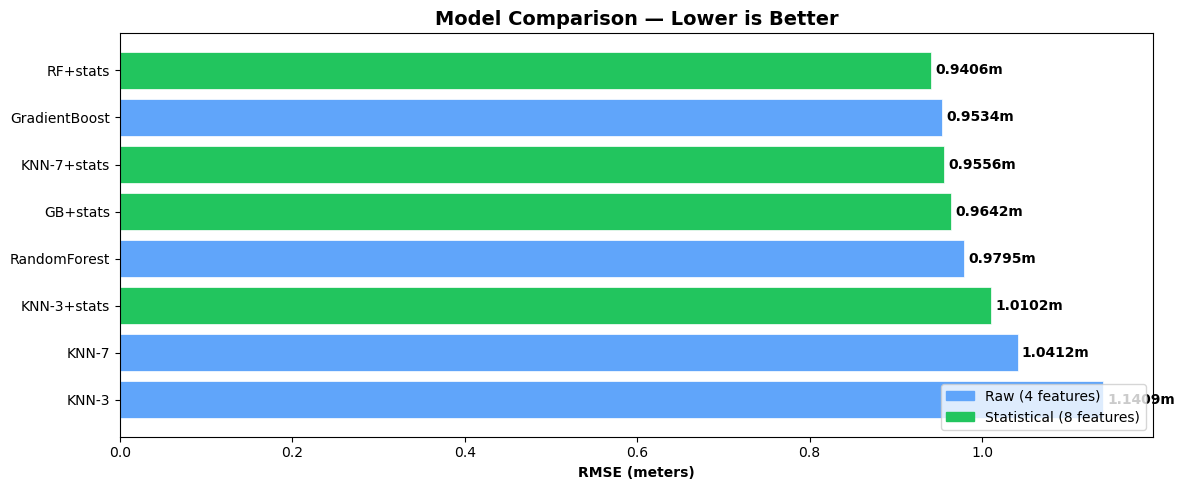

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
names = [r['name'] for r in results]
rmses = [r['rmse'] for r in results]
colors = ['#22c55e' if r['features'] == 'stat' else '#60a5fa' for r in results]
bars = ax.barh(names, rmses, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('RMSE (meters)', fontweight='bold')
ax.set_title('Model Comparison — Lower is Better', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, rmse in zip(bars, rmses):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{rmse:.4f}m', va='center', fontsize=10, fontweight='bold')

ax.legend([plt.Rectangle((0,0),1,1, color='#60a5fa'),
           plt.Rectangle((0,0),1,1, color='#22c55e')],
          ['Raw (4 features)', 'Statistical (8 features)'], loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Train Best Model on All Data & Save

In [22]:
best = results[0]
print(f'Training final model: {best["name"]}')
print(f'Features: {best["features"]} ({best["X"].shape[1]} dims)')

final_model = best['model']
final_model.fit(best['X'], best['y'])

# Verify on training data
y_pred = final_model.predict(best['X'])
train_rmse = np.sqrt(np.mean((best['y'] - y_pred)**2))
print(f'Training RMSE: {train_rmse:.4f}m')

# Save
MODEL_FILE = 'knn_model.pkl'
use_stats = best['features'] == 'stat'

with open(MODEL_FILE, 'wb') as f:
    pickle.dump({
        'model': final_model,
        'model_name': best['name'],
        'use_stat_features': use_stats,
        'window_size': WINDOW if use_stats else 1,
        'train_rmse': float(train_rmse),
        'cv_rmse': float(best['rmse']),
        'n_samples': len(best['X']),
        'n_features': int(best['X'].shape[1]),
        'grid_cols': GRID_COLS,
        'grid_rows': GRID_ROWS,
        'area_w': AREA_W,
        'area_h': AREA_H,
    }, f)

print(f'\n✅ Saved to {MODEL_FILE}')
print(f'   Model: {best["name"]}')
print(f'   Features: {"statistical (mean+std)" if use_stats else "raw RSSI"}')
print(f'   Window: {WINDOW if use_stats else "N/A"}')
print(f'   CV RMSE: {best["rmse"]:.4f}m')
print(f'   Train RMSE: {train_rmse:.4f}m')

Training final model: RF+stats
Features: stat (18 dims)
Training RMSE: 0.1164m

✅ Saved to knn_model.pkl
   Model: RF+stats
   Features: statistical (mean+std)
   Window: 5
   CV RMSE: 0.9406m
   Train RMSE: 0.1164m


## 6. Visualize Best Model Predictions

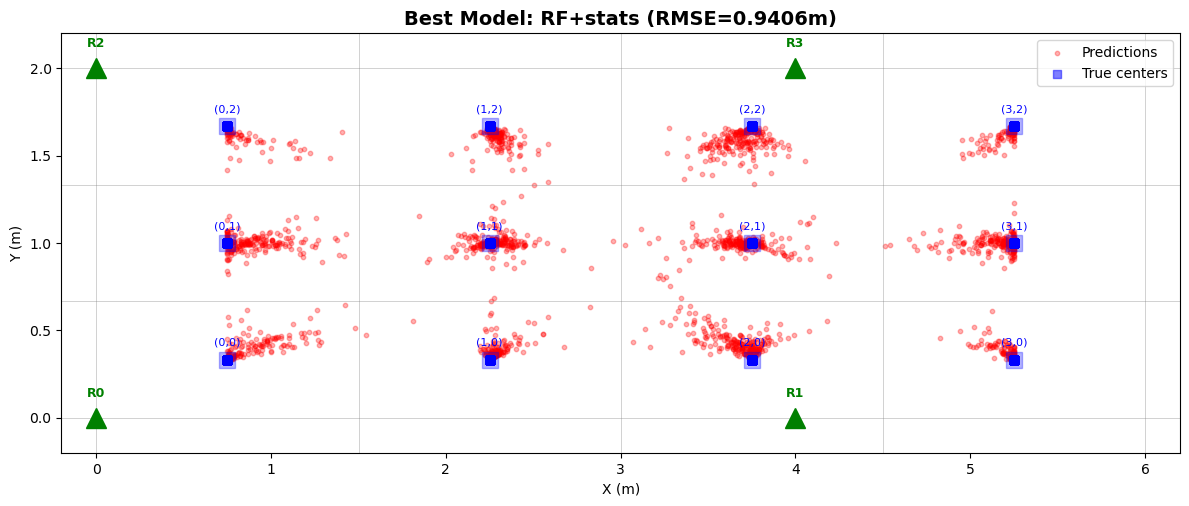

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.set_xlim(-0.2, AREA_W + 0.2)
ax.set_ylim(-0.2, AREA_H + 0.2)
ax.set_aspect('equal')
ax.set_title(f'Best Model: {best["name"]} (RMSE={best["rmse"]:.4f}m)', fontsize=14, fontweight='bold')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')

# Grid
for i in range(GRID_COLS + 1):
    ax.axvline(i * CELL_W, color='gray', linewidth=0.5, alpha=0.5)
for i in range(GRID_ROWS + 1):
    ax.axhline(i * CELL_H, color='gray', linewidth=0.5, alpha=0.5)

# Cell centers
for col in range(GRID_COLS):
    for row in range(GRID_ROWS):
        cx = col * CELL_W + CELL_W / 2
        cy = row * CELL_H + CELL_H / 2
        ax.plot(cx, cy, 's', color='blue', markersize=12, alpha=0.3)
        ax.text(cx, cy + 0.08, f'({col},{row})', ha='center', fontsize=8, color='blue')

ax.scatter(y_pred[:, 0], y_pred[:, 1], c='red', s=10, alpha=0.3, label='Predictions')
ax.scatter(best['y'][:, 0], best['y'][:, 1], c='blue', s=30, alpha=0.5, marker='s', label='True centers')

for i, (rx, ry) in enumerate([(0,0), (4,0), (0,2), (4,2)]):
    ax.plot(rx, ry, '^', color='green', markersize=14)
    ax.text(rx, ry + 0.12, f'R{i}', ha='center', fontsize=9, color='green', fontweight='bold')

ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('best_model_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Test Prediction

In [16]:
if use_stats:
    # Simulate a window of 5 identical readings
    test_rssi = [-45, -50, -42, -48]
    test_features = []
    for r in test_rssi:
        test_features.append(r)    # mean = value itself
        test_features.append(0.0)  # std = 0 (all same)
    test_input = np.array([test_features])
else:
    test_input = np.array([[-45, -50, -42, -48]])

pred = final_model.predict(test_input)
pred_col = int(pred[0][0] / CELL_W)
pred_row = int(pred[0][1] / CELL_H)
print(f'Test RSSI: {[-45, -50, -42, -48]}')
print(f'Predicted: x={pred[0][0]:.2f}m, y={pred[0][1]:.2f}m')
print(f'Cell: ({pred_col}, {pred_row})')

ValueError: X has 8 features, but StandardScaler is expecting 18 features as input.

In [25]:
# Find the best Random Forest model
import pickle
import numpy as np

rf_results = [r for r in results if 'rf' in r['name'].lower() or 'randomforest' in r['name'].lower()]
rf_results.sort(key=lambda r: r['rmse'])
best_rf = rf_results[0]

print(f'Training final RF model: {best_rf["name"]}')
print(f'Features: {best_rf["features"]} ({best_rf["X"].shape[1]} dims)')

rf_model = best_rf['model']
rf_model.fit(best_rf['X'], best_rf['y'])

# Verify on training data
y_pred_rf = rf_model.predict(best_rf['X'])
train_rmse_rf = np.sqrt(np.mean((best_rf['y'] - y_pred_rf)**2))
print(f'Training RMSE: {train_rmse_rf:.4f}m')

# Save
RF_MODEL_FILE = 'rf_model.pkl'
use_stats_rf = best_rf['features'] == 'stat'

with open(RF_MODEL_FILE, 'wb') as f:
    pickle.dump({
        'model': rf_model,
        'model_name': best_rf['name'],
        'use_stat_features': use_stats_rf,
        'window_size': WINDOW if use_stats_rf else 1,
        'train_rmse': float(train_rmse_rf),
        'cv_rmse': float(best_rf['rmse']),
        'n_samples': len(best_rf['X']),
        'n_features': int(best_rf['X'].shape[1]),
        'grid_cols': GRID_COLS,
        'grid_rows': GRID_ROWS,
        'area_w': AREA_W,
        'area_h': AREA_H,
    }, f)

print(f'\n✅ Saved to {RF_MODEL_FILE}')
print(f'   Model: {best_rf["name"]}')
print(f'   Features: {"statistical (mean+std)" if use_stats_rf else "raw RSSI"}')
print(f'   Window: {WINDOW if use_stats_rf else "N/A"}')
print(f'   CV RMSE: {best_rf["rmse"]:.4f}m')
print(f'   Train RMSE: {train_rmse_rf:.4f}m')

Training final RF model: RF+stats
Features: stat (18 dims)
Training RMSE: 0.1164m

✅ Saved to rf_model.pkl
   Model: RF+stats
   Features: statistical (mean+std)
   Window: 5
   CV RMSE: 0.9406m
   Train RMSE: 0.1164m


In [26]:
# Save every trained model in a separate pickle file
import pickle
import numpy as np

print("Saving all evaluated models separately...")

for res in results:
    model_var = res['model']
    model_name = res['name']
    
    # Needs a fit first on all data like the final models
    model_var.fit(res['X'], res['y'])
    
    y_pred_all = model_var.predict(res['X'])
    train_rmse_all = np.sqrt(np.mean((res['y'] - y_pred_all)**2))
    
    file_name = f'{model_name.replace("+", "_").replace("-", "_").lower()}_model.pkl'
    use_stats_all = res['features'] == 'stat'
    
    with open(file_name, 'wb') as f:
        pickle.dump({
            'model': model_var,
            'model_name': model_name,
            'use_stat_features': use_stats_all,
            'window_size': WINDOW if use_stats_all else 1,
            'train_rmse': float(train_rmse_all),
            'cv_rmse': float(res['rmse']),
            'n_samples': len(res['X']),
            'n_features': int(res['X'].shape[1]),
            'grid_cols': GRID_COLS,
            'grid_rows': GRID_ROWS,
            'area_w': AREA_W,
            'area_h': AREA_H,
        }, f)
        
    print(f'✅ Saved {model_name} to {file_name} (Train RMSE: {train_rmse_all:.4f}m)')
print("\nDone saving all models!")

Saving all evaluated models separately...
✅ Saved RF+stats to rf_stats_model.pkl (Train RMSE: 0.1164m)
✅ Saved GradientBoost to gradientboost_model.pkl (Train RMSE: 0.2565m)
✅ Saved KNN-7+stats to knn_7_stats_model.pkl (Train RMSE: 0.0153m)
✅ Saved GB+stats to gb_stats_model.pkl (Train RMSE: 0.0995m)
✅ Saved RandomForest to randomforest_model.pkl (Train RMSE: 0.1004m)
✅ Saved KNN-3+stats to knn_3_stats_model.pkl (Train RMSE: 0.0153m)
✅ Saved KNN-7 to knn_7_model.pkl (Train RMSE: 0.0368m)
✅ Saved KNN-3 to knn_3_model.pkl (Train RMSE: 0.0357m)

Done saving all models!
